<a href="https://colab.research.google.com/github/jasminef19/MyTelkomsel/blob/main/WEEK2%263/Week2_APPSREV_mytsel_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.5 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

In [ ]:
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Assuming the uploaded file is a CSV
  try:
    df_mytselrev = pd.read_csv(io.BytesIO(uploaded[fn]))
    print("Successfully loaded CSV into df_mytselrev")
  except pd.errors.ParserError:
      print(f"Error: Could not parse {fn} as a CSV. Please upload a valid CSV file.")
      df_mytselrev = pd.DataFrame() # Create an empty DataFrame if parsing fails
  except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df_mytselrev = pd.DataFrame()


Saving df_mytselrev_50kNew.csv to df_mytselrev_50kNew.csv
User uploaded file "df_mytselrev_50kNew.csv" with length 22412726 bytes
Successfully loaded CSV into df_mytselrev


In [ ]:
df_mytselrev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,8013d176-fdf1-4fc6-9b23-cec2cd1c4754,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,banyak sekali bos,5,0,9.1.0,2026-03-04 15:42:04,NaN,NaN,9.1.0
1,1291c18e-5cb4-409b-bd82-e0a34c1aca98,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bagus,5,0,9.1.0,2026-03-04 15:40:51,NaN,NaN,9.1.0
2,b88af38a-f45e-4436-908c-d1873c79e841,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,cerdas.cepat,5,0,9.1.0,2026-03-04 15:40:38,NaN,NaN,9.1.0
3,6987e130-a70d-495f-bc68-4d01945e14b0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jaringan gak stabil mending pake kartu lain aj...,1,0,6.12.2,2026-03-04 15:38:19,"Hai Kak Jax, Mohon maaf untuk ketidaknyamanann...",2026-03-04 16:08:26,6.12.2
4,7b084aa2-6a1b-4f21-baa6-ee5e80079c89,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Jelek sumpah jaringan tsel ini !! PARAH BANGET...,1,0,9.1.0,2026-03-04 15:37:11,"Hai Kak Resya, Mohon maaf untuk ketidaknyamana...",2026-03-04 16:24:17,9.1.0
...,...,...,...,...,...,...,...,...,...,...,...
49995,4dbfb43c-7a8c-48b6-9cad-3f35afcff31f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat mudah dan sangat membantu,5,0,NaN,2025-12-04 18:49:05,NaN,NaN,NaN
49996,1ec2f231-e09f-40ff-8c81-6f7cdc465da2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tanpa bonus parah,2,0,9.1.0,2025-12-04 18:48:21,Hai Kak PRASETIYA. Mohon maaf untuk ketidaknya...,2025-12-05 00:32:37,9.1.0
49997,108ef779-5016-47d1-b72e-343e1a37070c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gak guna ni aplikasi tidak berguna...!!! jgn d...,1,0,9.1.0,2025-12-04 18:47:19,Hai Kak Yandri. Mohon maaf untuk ketidaknyaman...,2025-05-01 02:33:23,9.1.0
49998,114fd2e7-7050-4216-942e-6efce3355f81,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sinyal nya min diperbaiki lagi , susah banget ...",2,0,9.0.1,2025-12-04 18:41:56,Hai Kak Naura. Mohon maaf untuk ketidaknyamana...,2025-12-05 00:33:04,9.0.1


In [ ]:
df_mytselrev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0    reviewId             50000 non-null  object
 1   userName              50000 non-null  object
 2   userImage             50000 non-null  object
 3   content               50000 non-null  object
 4   score                 50000 non-null  int64 
 5   thumbsUpCount         50000 non-null  int64 
 6   reviewCreatedVersion  42622 non-null  object
 7   at                    50000 non-null  object
 8   replyContent          28390 non-null  object
 9   repliedAt             28390 non-null  object
 10  appVersion            42622 non-null  object
dtypes: int64(2), object(9)
memory usage: 4.2+ MB


In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Download Indonesian stopwords if not available
nltk.download('stopwords')
indonesian_stopwords = set(stopwords.words('indonesian'))

# Assuming the text column is named 'text', update accordingly
text_column = 'content'  # Change this if the column has a different name

# Combine all text data into one string
all_text = ' '.join(df_mytselrev[text_column].dropna().astype(str))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_mytselrev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,banyak sekali bos,5,0,9.1.0,2026-03-04 15:42:04,NaN,NaN
1,sangat bagus,5,0,9.1.0,2026-03-04 15:40:51,NaN,NaN
2,cerdas.cepat,5,0,9.1.0,2026-03-04 15:40:38,NaN,NaN
3,jaringan gak stabil mending pake kartu lain aj...,1,0,6.12.2,2026-03-04 15:38:19,"Hai Kak Jax, Mohon maaf untuk ketidaknyamanann...",2026-03-04 16:08:26
4,Jelek sumpah jaringan tsel ini !! PARAH BANGET...,1,0,9.1.0,2026-03-04 15:37:11,"Hai Kak Resya, Mohon maaf untuk ketidaknyamana...",2026-03-04 16:24:17
...,...,...,...,...,...,...,...
49995,sangat mudah dan sangat membantu,5,0,NaN,2025-12-04 18:49:05,NaN,NaN
49996,tanpa bonus parah,2,0,9.1.0,2025-12-04 18:48:21,Hai Kak PRASETIYA. Mohon maaf untuk ketidaknya...,2025-12-05 00:32:37
49997,gak guna ni aplikasi tidak berguna...!!! jgn d...,1,0,9.1.0,2025-12-04 18:47:19,Hai Kak Yandri. Mohon maaf untuk ketidaknyaman...,2025-05-01 02:33:23
49998,"sinyal nya min diperbaiki lagi , susah banget ...",2,0,9.0.1,2025-12-04 18:41:56,Hai Kak Naura. Mohon maaf untuk ketidaknyamana...,2025-12-05 00:33:04


##Stopwords Removal
Indonesian Stopwords

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian')

# Display first 20 stopwords
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
print(len(indonesian_stopwords))

758


In [ ]:
indonesian_stopwords

['ada',
 'adalah',
 'adanya',
 'adapun',
 'agak',
 'agaknya',
 'agar',
 'akan',
 'akankah',
 'akhir',
 'akhiri',
 'akhirnya',
 'aku',
 'akulah',
 'amat',
 'amatlah',
 'anda',
 'andalah',
 'antar',
 'antara',
 'antaranya',
 'apa',
 'apaan',
 'apabila',
 'apakah',
 'apalagi',
 'apatah',
 'artinya',
 'asal',
 'asalkan',
 'atas',
 'atau',
 'ataukah',
 'ataupun',
 'awal',
 'awalnya',
 'bagai',
 'bagaikan',
 'bagaimana',
 'bagaimanakah',
 'bagaimanapun',
 'bagi',
 'bagian',
 'bahkan',
 'bahwa',
 'bahwasanya',
 'baik',
 'bakal',
 'bakalan',
 'balik',
 'banyak',
 'bapak',
 'baru',
 'bawah',
 'beberapa',
 'begini',
 'beginian',
 'beginikah',
 'beginilah',
 'begitu',
 'begitukah',
 'begitulah',
 'begitupun',
 'bekerja',
 'belakang',
 'belakangan',
 'belum',
 'belumlah',
 'benar',
 'benarkah',
 'benarlah',
 'berada',
 'berakhir',
 'berakhirlah',
 'berakhirnya',
 'berapa',
 'berapakah',
 'berapalah',
 'berapapun',
 'berarti',
 'berawal',
 'berbagai',
 'berdatangan',
 'beri',
 'berikan',
 'berikut'

,Word,Frequency
0,paket,8063
1,telkomsel,7664
2,mahal,7272
3,jaringan,6742
4,nya,6430
...,...,...
95,bayar,537
96,main,535
97,kaya,533
98,.,533


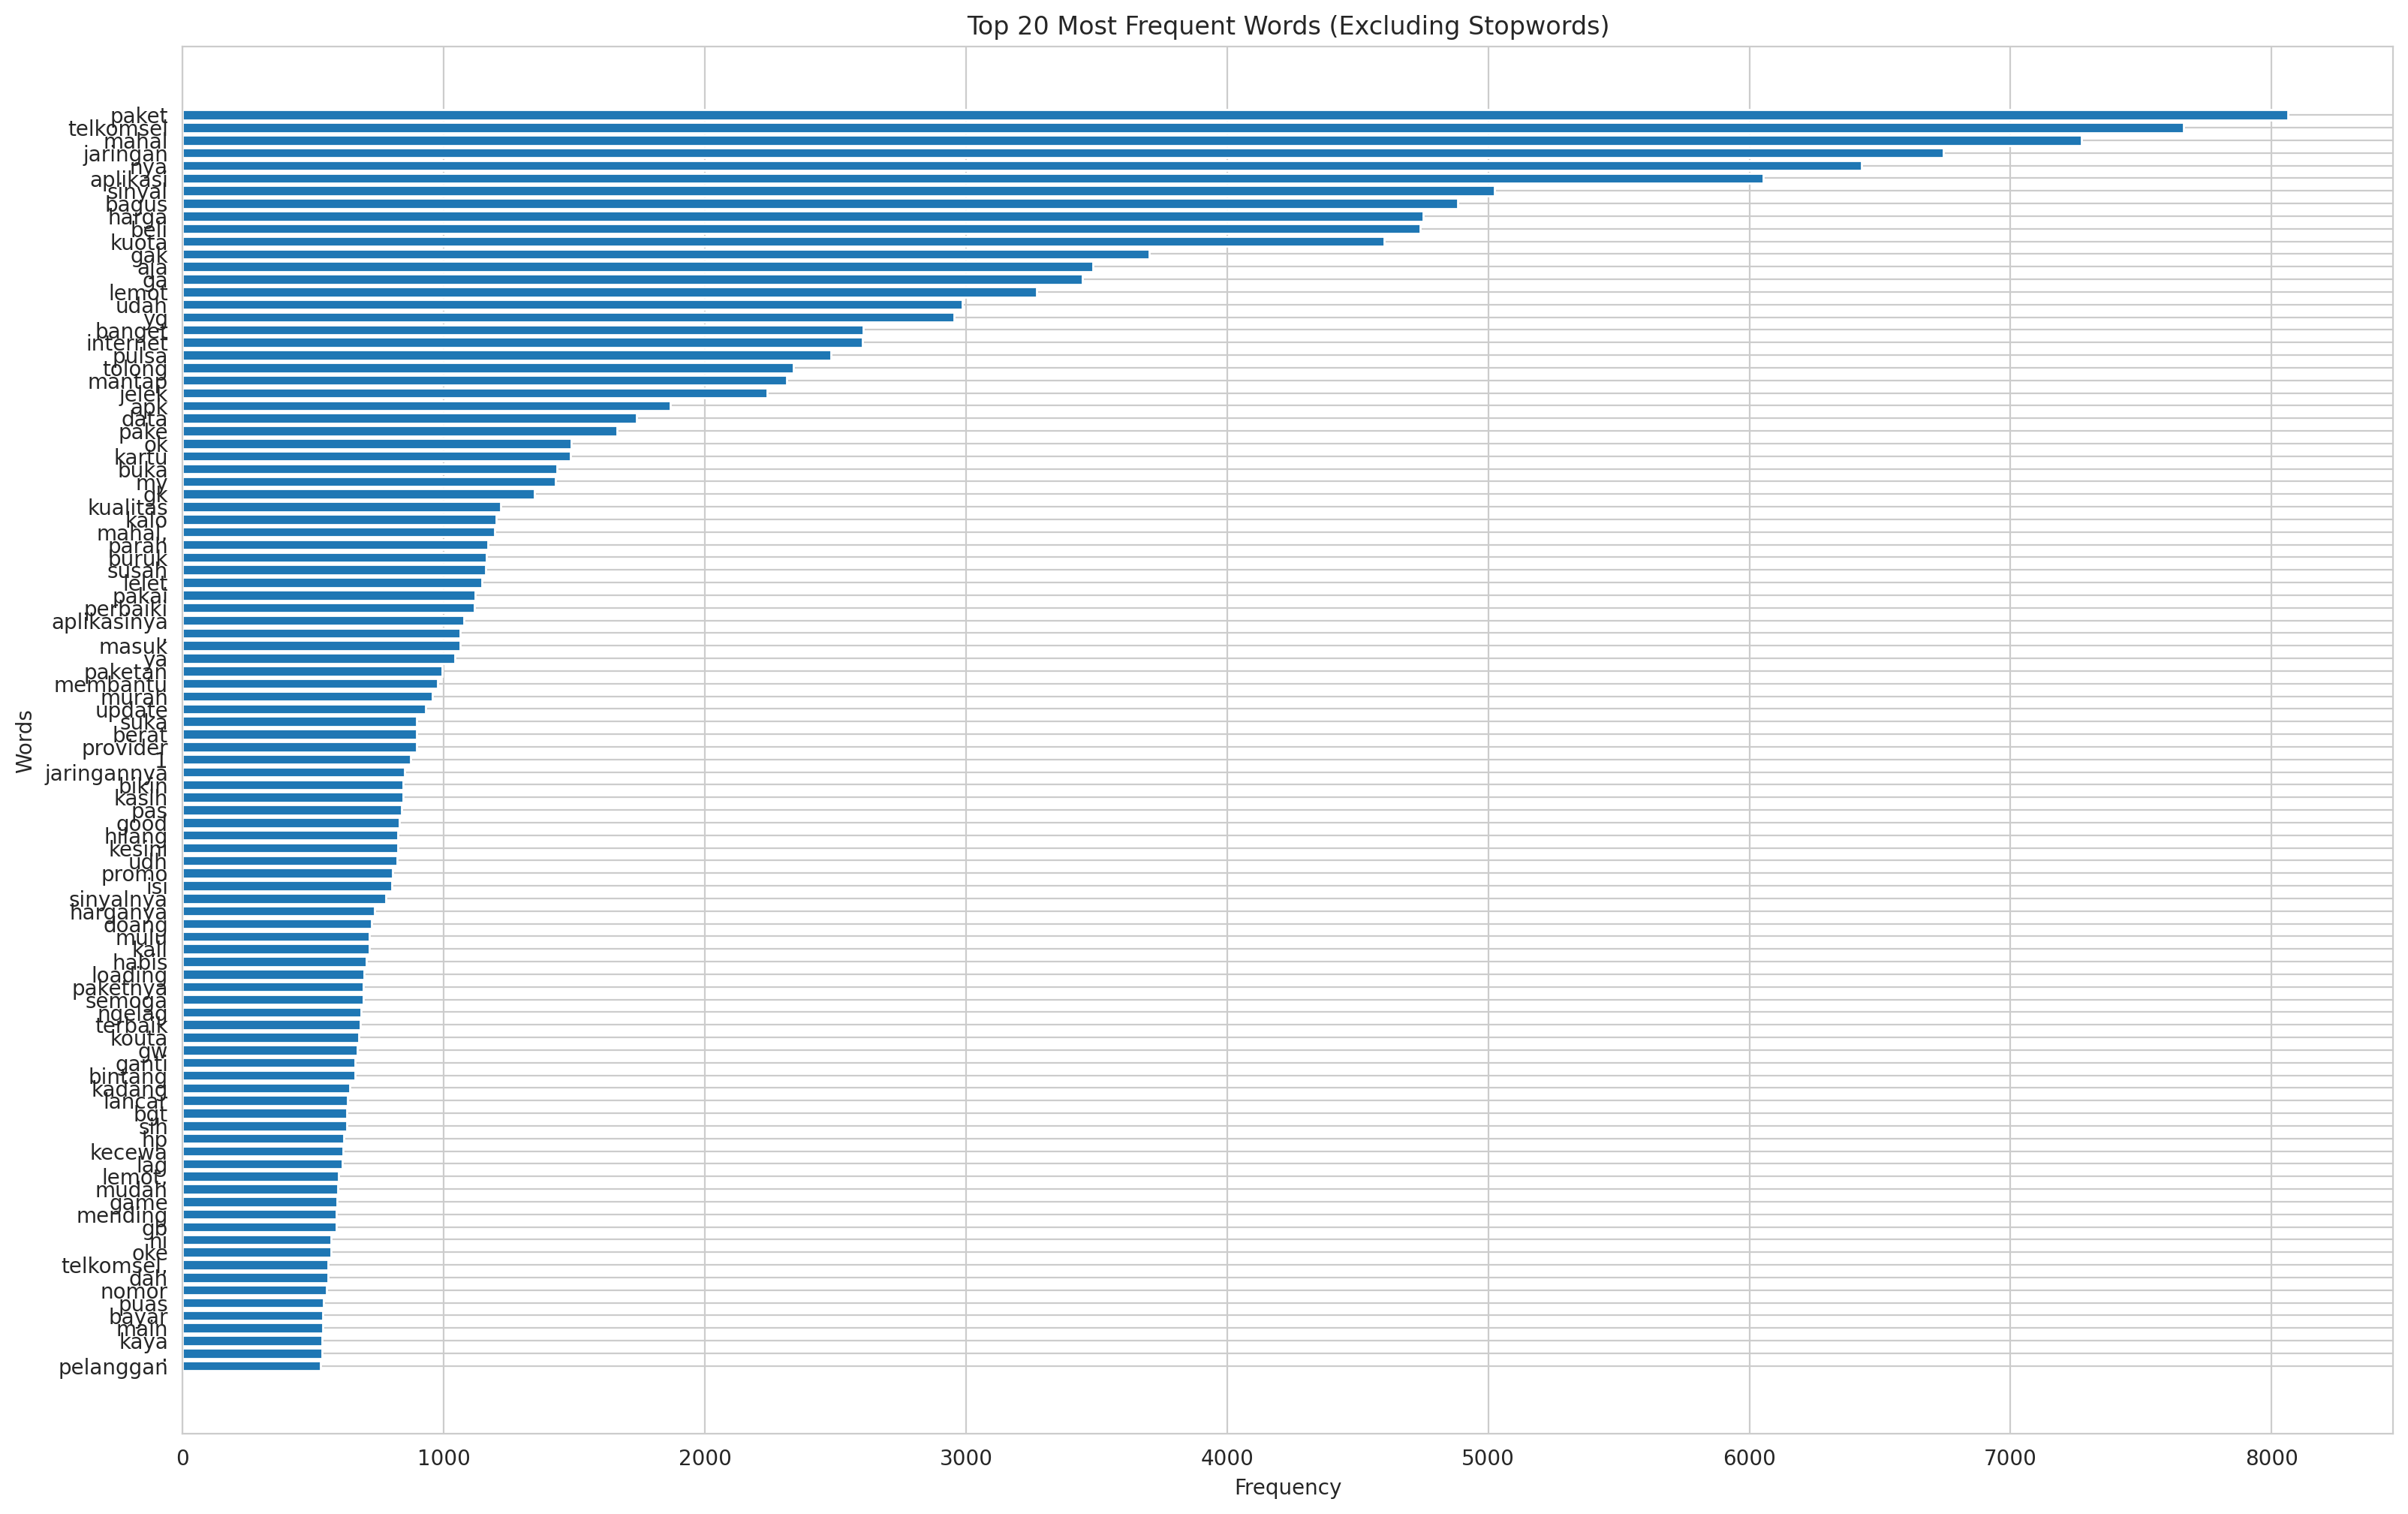

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt

# Assuming the text column is named 'text', update accordingly
text_column = 'content'  # Change this if the column has a different name

# Combine all text data into one string
all_text = ' '.join(df_mytselrev[text_column].dropna().astype(str))

# Tokenize words and remove stopwords
words = all_text.split()
filtered_words = [word.lower() for word in words if word.lower() not in indonesian_stopwords]

# Count frequent words
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(100)

# Convert to DataFrame for better visualization
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Display the most common words
display(word_freq_df)

# Plot the frequent words
plt.figure(figsize=(19, 12))
plt.barh(word_freq_df['Word'][::-1], word_freq_df['Frequency'][::-1])
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words (Excluding Stopwords)")
plt.show()

In [ ]:
common_words

[('paket', 8063),
 ('telkomsel', 7664),
 ('mahal', 7272),
 ('jaringan', 6742),
 ('nya', 6430),
 ('aplikasi', 6052),
 ('sinyal', 5024),
 ('bagus', 4882),
 ('harga', 4750),
 ('beli', 4738),
 ('kuota', 4602),
 ('gak', 3701),
 ('aja', 3485),
 ('ga', 3446),
 ('lemot', 3271),
 ('udah', 2985),
 ('yg', 2955),
 ('banget', 2607),
 ('internet', 2602),
 ('pulsa', 2483),
 ('tolong', 2339),
 ('mantap', 2313),
 ('jelek', 2237),
 ('apk', 1867),
 ('data', 1739),
 ('pake', 1664),
 ('ok', 1489),
 ('kartu', 1484),
 ('buka', 1434),
 ('my', 1427),
 ('gk', 1348),
 ('kualitas', 1218),
 ('kalo', 1199),
 ('mahal,', 1195),
 ('parah', 1169),
 ('buruk', 1163),
 ('susah', 1160),
 ('lelet', 1146),
 ('pakai', 1121),
 ('perbaiki', 1117),
 ('aplikasinya', 1076),
 (',', 1063),
 ('masuk', 1062),
 ('ya', 1042),
 ('paketan', 994),
 ('membantu', 975),
 ('murah', 955),
 ('update', 930),
 ('suka', 897),
 ('berat', 896),
 ('provider', 895),
 ('1', 872),
 ('jaringannya', 849),
 ('bikin', 845),
 ('kasih', 845),
 ('pas', 839),
 (

Homework: WEEK 3/ 11 maret 2026 (TUGAS 2)

Bisa menambahkan, list kata dari most frequent words, kata2 yg tidak memiliki arti penting (eg ga (no-2), gak-no4) ke list indonesian_stopwords
